#0Sequential retrieval [GRU4Rec]

**Author:** [Abheesht Sharma](https://github.com/abheesht17/), [Fabien Hertschuh](https://github.com/hertschuh/)<br>
**Date created:** 2025/04/28<br>
**Last modified:** 2025/04/28<br>
**Description:** Recommend movies using a GRU-based sequential retrieval model.

## Introduction

In this example, we are going to build a sequential retrieval model. Sequential
recommendation is a popular model that looks at a sequence of items that users
have interacted with previously and then predicts the next item. Here, the order
of the items within each sequence matters. So, we are going to use a recurrent
neural network to model the sequential relationship. For more details,
please refer to the [GRU4Rec](https://arxiv.org/abs/1511.06939) paper.

Let's begin by choosing JAX as the backend we want to run on, and import all
the necessary libraries.

In [ ]:
!pip install -q keras-rs

In [ ]:
!pip install jax

In [1]:
import os

os.environ["KERAS_BACKEND"] = "jax"  # `"tensorflow"`/`"torch"`

import collections
import os
import random

import keras
import pandas as pd
import tensorflow as tf  # Needed only for the dataset

import keras_rs

I0000 00:00:1775179133.680235  254357 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775179133.681762  254357 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775179135.395610  254357 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775179135.396524  254357 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Let's also define all important variables/hyperparameters below.

In [2]:
DATA_DIR = "./raw/data/"

# MovieLens-specific variables
MOVIELENS_1M_URL = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
MOVIELENS_ZIP_HASH = "a6898adb50b9ca05aa231689da44c217cb524e7ebd39d264c56e2832f2c54e20"

RATINGS_FILE_NAME = "ratings.dat"
MOVIES_FILE_NAME = "movies.dat"

# Data processing args
MAX_CONTEXT_LENGTH = 10
MIN_SEQUENCE_LENGTH = 3

RATINGS_DATA_COLUMNS = ["UserID", "MovieID", "Rating", "Timestamp"]
MOVIES_DATA_COLUMNS = ["MovieID", "Title", "Genres"]
MIN_RATING = 2

# Training/model args
BATCH_SIZE = 4096
TEST_BATCH_SIZE = 2048
EMBEDDING_DIM = 32
NUM_EPOCHS = 5
LEARNING_RATE = 0.005

## Dataset

Next, we need to prepare our dataset. Like we did in the
[basic retrieval](/keras_rs/examples/basic_retrieval/)
example, we are going to use the MovieLens dataset.

The dataset preparation step is fairly involved. The original ratings dataset
contains `(user, movie ID, rating, timestamp)` tuples (among other columns,
which are not important for this example). Since we are dealing with sequential
retrieval, we need to create movie sequences for every user, where the sequences
are ordered by timestamp.

Let's start by downloading and reading the dataset.

In [3]:
# Download the MovieLens dataset.
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

path_to_zip = keras.utils.get_file(
    fname="ml-1m.zip",
    origin=MOVIELENS_1M_URL,
    file_hash=MOVIELENS_ZIP_HASH,
    hash_algorithm="sha256",
    extract=True,
    cache_dir=DATA_DIR,
)
movielens_extracted_dir = os.path.join(
    os.path.dirname(path_to_zip),
    "ml-1m_extracted",
    "ml-1m",
)


# Read the dataset.
def read_data(data_directory, min_rating=None):
    """Read movielens ratings.dat and movies.dat file
    into dataframe.
    """

    ratings_df = pd.read_csv(
        os.path.join(data_directory, RATINGS_FILE_NAME),
        sep="::",
        names=RATINGS_DATA_COLUMNS,
        encoding="unicode_escape",
        engine="python",
    )
    ratings_df["Timestamp"] = ratings_df["Timestamp"].apply(int)

    # Remove movies with `rating < min_rating`.
    if min_rating is not None:
        ratings_df = ratings_df[ratings_df["Rating"] >= min_rating]

    movies_df = pd.read_csv(
        os.path.join(data_directory, MOVIES_FILE_NAME),
        sep="::",
        names=MOVIES_DATA_COLUMNS,
        encoding="unicode_escape",
        engine="python",
    )
    return ratings_df, movies_df


ratings_df, movies_df = read_data(
    data_directory=movielens_extracted_dir, min_rating=MIN_RATING
)

# Need to know #movies so as to define embedding layers.
movies_count = movies_df["MovieID"].max()

In [4]:
ratings_df

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000203,6040,1090,3,956715518
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [5]:
movies_df

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


Now that we have read the dataset, let's create sequences of movies
for every user. Here is the function for doing just that.

In [6]:
def get_movie_sequence_per_user(ratings_df):
    """Get movieID sequences for every user."""
    sequences = collections.defaultdict(list)

    for user_id, movie_id, rating, timestamp in ratings_df.values:
        sequences[user_id].append(
            {
                "movie_id": movie_id,
                "timestamp": timestamp,
                "rating": rating,
            }
        )

    # Sort movie sequences by timestamp for every user.
    for user_id, context in sequences.items():
        context.sort(key=lambda x: x["timestamp"])
        sequences[user_id] = context

    return sequences

We need to do some filtering and processing before we proceed
with training the model:

1. Form sequences of all lengths up to
   `min(user_sequence_length, MAX_CONTEXT_LENGTH)`. So, every user
   will have multiple sequences corresponding to it.
2. Get labels, i.e., Given a sequence of length `n`, the first
   `n-1` tokens will be fed to the model as input, and the label
   will be the last token.
3. Remove all user sequences with less than `MIN_SEQUENCE_LENGTH`
   movies.
4. Pad all sequences to `MAX_CONTEXT_LENGTH`.

An important point to note is how we form the train-test splits. We do not
form the entire dataset of sequences and then split it into train and test.
Instead, for every user, we take the last sequence to be part of the test set,
and all other sequences to be part of the train set. This is to prevent data
leakage.

In [7]:
sequences = get_movie_sequence_per_user(ratings_df)
sequences[1]

[{'movie_id': np.int64(3186),
  'timestamp': np.int64(978300019),
  'rating': np.int64(4)},
 {'movie_id': np.int64(1270),
  'timestamp': np.int64(978300055),
  'rating': np.int64(5)},
 {'movie_id': np.int64(1721),
  'timestamp': np.int64(978300055),
  'rating': np.int64(4)},
 {'movie_id': np.int64(1022),
  'timestamp': np.int64(978300055),
  'rating': np.int64(5)},
 {'movie_id': np.int64(2340),
  'timestamp': np.int64(978300103),
  'rating': np.int64(3)},
 {'movie_id': np.int64(1836),
  'timestamp': np.int64(978300172),
  'rating': np.int64(5)},
 {'movie_id': np.int64(3408),
  'timestamp': np.int64(978300275),
  'rating': np.int64(4)},
 {'movie_id': np.int64(2804),
  'timestamp': np.int64(978300719),
  'rating': np.int64(5)},
 {'movie_id': np.int64(1207),
  'timestamp': np.int64(978300719),
  'rating': np.int64(4)},
 {'movie_id': np.int64(1193),
  'timestamp': np.int64(978300760),
  'rating': np.int64(5)},
 {'movie_id': np.int64(720),
  'timestamp': np.int64(978300760),
  'rating': np.

In [8]:
def generate_examples_from_user_sequences(sequences):
    """Generates sequences for all users, with padding, truncation, etc."""

    def generate_examples_from_user_sequence(sequence):
        """Generates examples for a single user sequence."""

        train_examples = []
        test_examples = []
        for label_idx in range(1, len(sequence)):
            start_idx = max(0, label_idx - MAX_CONTEXT_LENGTH)
            context = sequence[start_idx:label_idx]

            # Padding
            while len(context) < MAX_CONTEXT_LENGTH:
                context.append(
                    {
                        "movie_id": 0,
                        "timestamp": 0,
                        "rating": 0.0,
                    }
                )

            label_movie_id = int(sequence[label_idx]["movie_id"])
            context_movie_id = [int(movie["movie_id"]) for movie in context]

            example = {
                "context_movie_id": context_movie_id,
                "label_movie_id": label_movie_id,
            }

            if label_idx == len(sequence) - 1:
                test_examples.append(example)
            else:
                train_examples.append(example)

        return train_examples, test_examples

    all_train_examples = []
    all_test_examples = []
    for sequence in sequences.values():
        if len(sequence) < MIN_SEQUENCE_LENGTH:
            continue

        user_train_examples, user_test_example = generate_examples_from_user_sequence(
            sequence
        )

        all_train_examples.extend(user_train_examples)
        all_test_examples.extend(user_test_example)

    return all_train_examples, all_test_examples

In [9]:
train_examples, test_examples = generate_examples_from_user_sequences(sequences)

In [ ]:
#context_movie_id 는 시청이력,   label_movie_id 는 이후 시청한 컨텐츠
#context_length 는 10 이고 부족한 데이터는 0으로 padding 

In [10]:
train_examples[5]

{'context_movie_id': [3186, 1270, 1721, 1022, 2340, 1836, 0, 0, 0, 0],
 'label_movie_id': 3408}

In [11]:
test_examples[3]

{'context_movie_id': [2366,
  1201,
  2692,
  2947,
  1214,
  3418,
  3702,
  1240,
  2951,
  1036],
 'label_movie_id': 1954}

Let's split the dataset into train and test sets. Also, we need to
change the format of the dataset dictionary so as to enable conversion
to a `tf.data.Dataset` object.

In [12]:
def list_of_dicts_to_dict_of_lists(list_of_dicts):
    """Convert list of dictionaries to dictionary of lists for
    `tf.data` conversion.
    """
    dict_of_lists = collections.defaultdict(list)
    for dictionary in list_of_dicts:
        for key, value in dictionary.items():
            dict_of_lists[key].append(value)
    return dict_of_lists

train_examples = list_of_dicts_to_dict_of_lists(train_examples)
test_examples = list_of_dicts_to_dict_of_lists(test_examples)

In [13]:
train_ds = tf.data.Dataset.from_tensor_slices(train_examples).map(
    lambda x: (x["context_movie_id"], x["label_movie_id"])
)
test_ds = tf.data.Dataset.from_tensor_slices(test_examples).map(
    lambda x: (x["context_movie_id"], x["label_movie_id"])
)

E0000 00:00:1775179186.214997  254357 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775179186.215381  254678 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775179186.252988  254357 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [14]:
train_ds

<_MapDataset element_spec=(TensorSpec(shape=(10,), dtype=tf.int32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

We need to batch our datasets. We also user `cache()` and `prefetch()`
for better performance.
cache()는 첫번째 학습때 데이터를 읽고 가공한 결과를 메모리에 저장,두번째 학습 부터는 메모리의  결과를 바로 꺼내 쓰기 때문에 데이터 로딩 시간이 크게 줄어듬
prefetch() 는 현재 배치를 학습하고 있는 동안 다음 배치를 백그라운드 에서 미리 준비  GPU 가 놀지 않도록...   AUTOTUNE  은 배치의 개수를 자동으로 알아서 결정

In [15]:
train_ds = train_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(TEST_BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

Let's print out one batch.

In [16]:
for sample in train_ds.take(1):
    print(sample)

(<tf.Tensor: shape=(4096, 10), dtype=int32, numpy=
array([[3186,    0,    0, ...,    0,    0,    0],
       [3186, 1270,    0, ...,    0,    0,    0],
       [3186, 1270, 1721, ...,    0,    0,    0],
       ...,
       [2194, 1291, 2159, ...,  300, 2076,  866],
       [1291, 2159, 1012, ..., 2076,  866, 2206],
       [2159, 1012, 1092, ...,  866, 2206,  377]],
      shape=(4096, 10), dtype=int32)>, <tf.Tensor: shape=(4096,), dtype=int32, numpy=
array([1270, 1721, 1022, ..., 2206,  377, 1357],
      shape=(4096,), dtype=int32)>)


W0000 00:00:1775179188.215123  254713 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## Model and Training

In the basic retrieval example, we used one query tower for the
user, and the candidate tower for the candidate movie. We are
going to use a two-tower architecture here as well. However,
we use the query tower with a Gated Recurrent Unit (GRU) layer
to encode the sequence of historical movies, and keep the same
candidate tower for the candidate movie.

Note: Take a look at how the labels are defined. The label tensor
(of shape `(batch_size, batch_size)`) contains one-hot vectors. The idea
is: for every sample, consider movie IDs corresponding to other samples in
the batch as negatives.

In [17]:
class SequentialRetrievalModel(keras.Model):
    """Create the sequential retrieval model.

    Args:
      movies_count: Total number of unique movies in the dataset.
      embedding_dimension: Output dimension for movie embedding tables.
    """

    def __init__(
        self,
        movies_count,
        embedding_dimension=128,
        **kwargs,
    ):
        super().__init__(**kwargs)
        # Our query tower, simply an embedding table followed by
        # a GRU unit. This encodes sequence of historical movies.
        # 역할: 사용자가 지금까지 본 영화들의 순서를 분석하여 "이 사용자는 지금 어떤 취향/상태인가?"를 하나의 수학적 벡터(숫자 배열)로 요약합니다.
        # Embedding: 영화 ID(번호)를 모델이 이해할 수 있는 벡터(차원: embedding_dimension)로 바꿉니다. (movies_count + 1을 하는 이유는 보통 ID '0'을 빈 공간(Padding)을 채우는 용도로 쓰기 때문입니다.)
        # GRU: 시계열 데이터(순서가 있는 데이터)를 처리하는 데 특화된 딥러닝 층입니다. 과거부터 최근까지 본 영화의 흐름을 기억하고 종합합니다.
        self.query_model = keras.Sequential(
            [
                keras.layers.Embedding(movies_count + 1, embedding_dimension),
                keras.layers.GRU(embedding_dimension),
            ]
        )

        # Our candidate tower, simply an embedding table.
        # 역할: 추천의 대상이 되는 개별 영화 자체의 특성을 벡터로 변환합니다. (여기는 순서가 필요 없으므로 단순한 Embedding 층 하나만 사용합니다.)
        self.candidate_model = keras.layers.Embedding(movies_count + 1, embedding_dimension)

        # The layer that performs the retrieval.
        # 실제 서비스(예측) 단계에서, 사용자 벡터와 가장 비슷한(점수가 높은) 영화 벡터 상위 10개(k=10)를 무식하지만 확실하게(BruteForce) 찾아내는 도구입니다.
        self.retrieval = keras_rs.layers.BruteForceRetrieval(k=10, return_scores=False)
        #모델이 정답을 맞혔는지 틀렸는지 채점하는 기준(손실 함수)입니다.
        self.loss_fn = keras.losses.CategoricalCrossentropy(
            from_logits=True,
        )

    def build(self, input_shape):
        self.query_model.build(input_shape)
        self.candidate_model.build(input_shape)

        # In this case, the candidates are directly the movie embeddings.
        # We take a shortcut and directly reuse the variable.
        # 검색기(retrieval)가 영화를 찾으려면 전체 영화의 백과사전(임베딩 맵)이 필요한데, 
        # 후보 탑(candidate_model)이 이미 학습하고 있는 영화 백과사전을 그대로 공유(Shortcut) 하도록 연결해 준 것입니다.
        self.retrieval.candidate_embeddings = self.candidate_model.embeddings
        self.retrieval.build(input_shape)
        super().build(input_shape)

    def call(self, inputs, training=False):
        #사용자의 시청 기록을 질의 벡터(query_embeddings) 로 만듭니다.
        query_embeddings = self.query_model(inputs)
        result = {
            "query_embeddings": query_embeddings,
        }

        if not training:
            # Skip the retrieval of top movies during training as the
            # predictions are not used.
            # 질의 벡터를 바탕으로 전체 영화 중 가장 잘 맞는 상위 10개 영화를 검색
            result["predictions"] = self.retrieval(query_embeddings)
        return result

    def compute_loss(self, x, y, y_pred, sample_weight, training=True):
        candidate_id = y
        #사용자의 현재 취향 벡터
        query_embeddings = y_pred["query_embeddings"]
        #self.candidate_model(y)를 통해 구한 정답 영화의 벡터
        candidate_embeddings = self.candidate_model(candidate_id)

        num_queries = keras.ops.shape(query_embeddings)[0]
        num_candidates = keras.ops.shape(candidate_embeddings)[0]

        # One-hot vectors for labels.
        # 배치(Batch)로 들어온 여러 명의 사용자와 각각의 정답 영화들을 모아놓고 봅니다.
        # 1번 사용자의 정답은 1번 영화, 2번 사용자의 정답은 2번 영화가 되어야 합니다. 
        # 이를 단위 행렬로 만들면 완벽한 정답지가 됩니다. (배치 내의 다른 사람의 정답 영화를 '나의 오답'으로 재활용하여 학습 효율을 극대화하는 천재적인 방법입니다.)
        labels = keras.ops.eye(num_queries, num_candidates)

        # Compute the affinity score by multiplying the two embeddings.
        # 사용자의 취향 벡터와 영화의 특성 벡터를 곱합니다. 두 벡터의 성향이 비슷할수록 점수가 높게 나옵니다.
        scores = keras.ops.matmul(
            query_embeddings, keras.ops.transpose(candidate_embeddings)
        )

        # 최종적으로 내가 예측한 점수판(scores)과 완벽한 정답지(labels)를 비교하여 얼마나 틀렸는지(오차)를 계산하여 반환합니다. 
        # 이 오차를 줄이는 방향으로 모델이 스스로를 업데이트합니다.
        return self.loss_fn(labels, scores, sample_weight)

    def get_movie_embedding(self, movie_ids):
        # 입력된 영화 ID에 대한 임베딩 벡터를 반환합니다.
        # candidate_model이 곧 영화의 Embedding Layer이므로, ID를 통과시키기만 하면 해당 벡터가 나옵니다.
        return self.candidate_model(movie_ids)

Let's instantiate, compile and train our model.

In [18]:
model = SequentialRetrievalModel(
    movies_count=movies_count, embedding_dimension=EMBEDDING_DIM
)

# Compile. Use Adam Weight algorithm as optimizer. Best for preventing Overfitting issue.
model.compile(optimizer=keras.optimizers.AdamW(learning_rate=LEARNING_RATE))

# Train.
model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=NUM_EPOCHS,
)

Epoch 1/5


W0000 00:00:1775179197.005978  254357 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


228/228 ━━━━━━━━━━━━━━━━━━━━ 37s 160ms/step - loss: 7.6046 - val_loss: 6.7902
Epoch 2/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 35s 155ms/step - loss: 6.9761 - val_loss: 6.5383
Epoch 3/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 35s 154ms/step - loss: 6.7872 - val_loss: 6.4332
Epoch 4/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 36s 158ms/step - loss: 6.6827 - val_loss: 6.3678
Epoch 5/5
228/228 ━━━━━━━━━━━━━━━━━━━━ 36s 158ms/step - loss: 6.6136 - val_loss: 6.3333


In [19]:
movies_count = 1000

# 1. 1번부터 movies_count까지의 모든 영화 ID 텐서 생성
# (0번은 보통 패딩용이므로 제외하거나 필요에 따라 포함)
all_movie_ids = tf.range(1, movies_count + 1)

# 2. 방금 만든 메서드를 이용해 전체 영화 임베딩 한 번에 추출
all_movie_embeddings = model.get_movie_embedding(all_movie_ids)
all_movie_embeddings[:1]

Array([[ 0.6267464 , -0.49719208,  0.3642385 , -0.8456246 ,  0.17125306,
        -0.16314356,  0.22158612,  0.19264033,  0.08905257, -0.38307384,
         0.13801104, -0.02590517,  0.00360076,  0.52571046, -0.30604672,
         0.38557366,  0.18768455, -0.07069937, -0.4436099 ,  0.09800959,
         0.2952234 ,  0.1414119 , -0.6087445 ,  0.0712577 ,  0.4833835 ,
        -0.17002904, -0.81829536,  0.25794694, -0.12053115, -0.00433401,
         0.7478982 ,  0.20306551]], dtype=float32)

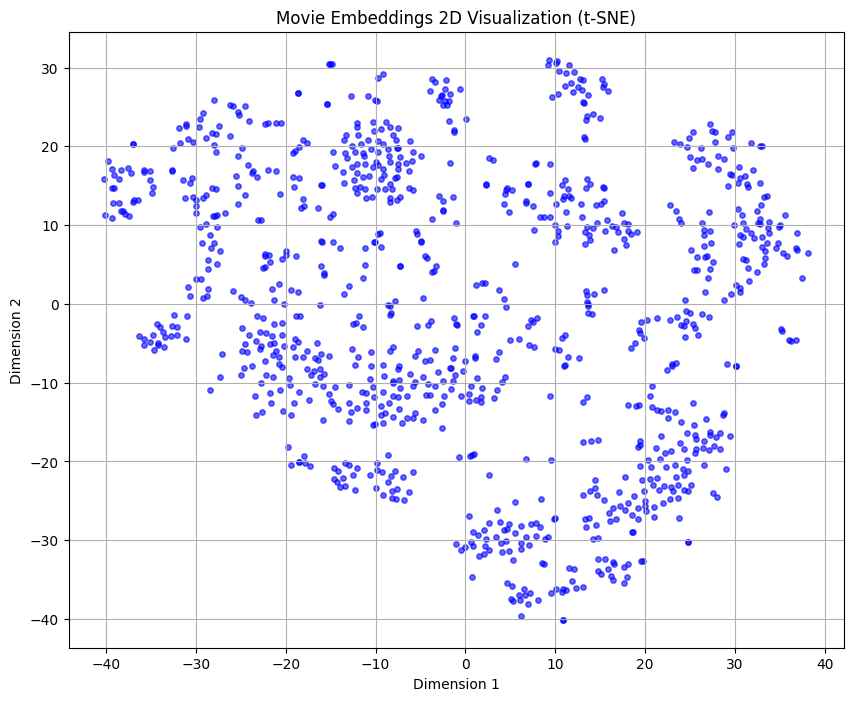

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# 1. t-SNE 모델 초기화 및 2차원으로 학습/변환 (시간이 조금 걸릴 수 있습니다)
# perplexity: 보통 5 ~ 50 사이의 값을 주며, 군집의 촘촘함을 결정합니다.
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(all_movie_embeddings)
# 2. Matplotlib을 이용한 2D 산점도(Scatter Plot) 시각화
plt.figure(figsize=(10, 8))
# x축엔 0번째 열, y축엔 1번째 열의 데이터를 넣고 점(산점도)을 찍습니다.
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6, s=15, c='blue')

plt.title("Movie Embeddings 2D Visualization (t-SNE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

## Making predictions

Now that we have a model, we would like to be able to make predictions.

So far, we have only handled movies by id. Now is the time to create a mapping
keyed by movie IDs to be able to surface the titles.

In [21]:
movie_id_to_movie_title = dict(zip(movies_df["MovieID"], movies_df["Title"]))
movie_id_to_movie_title[0] = ""  # Because id 0 is not in the dataset.

We then simply use the Keras `model.predict()` method. Under the hood, it calls
the `BruteForceRetrieval` layer to perform the actual retrieval.

Note that this model can retrieve movies already watched by the user. We could
easily add logic to remove them if that is desirable.

In [22]:
print("\n==> Movies the user has watched:")
movie_sequence = test_ds.unbatch().take(1)
for element in movie_sequence:
    for movie_id in element[0][:-1]:
        print(movie_id_to_movie_title[movie_id.numpy()], end=", ")
    print(movie_id_to_movie_title[element[0][-1].numpy()])

predictions = model.predict(movie_sequence.batch(1))
predictions


==> Movies the user has watched:
Beauty and the Beast (1991), Tarzan (1999), Close Shave, A (1995), Aladdin (1992), Toy Story (1995), Bug's Life, A (1998), Antz (1998), Hunchback of Notre Dame, The (1996), Hercules (1997), Mulan (1998)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


{'predictions': array([[1566, 1405,  783,  661, 1688, 2394, 2876, 2294, 1907, 1064]],
       dtype=int32),
 'query_embeddings': array([[-0.99167985, -0.93604654,  0.9989967 , -0.97839576,  0.99136007,
          0.91373634, -0.5793054 ,  0.98324156,  0.552624  ,  0.06546564,
         -0.98308474,  0.5423824 , -0.99873203,  0.99974126, -0.7747616 ,
          0.9709527 , -0.4352001 , -0.7766244 , -0.9711482 ,  0.8442773 ,
         -0.886836  ,  0.919376  , -0.7507351 ,  0.9690677 ,  0.7498955 ,
         -0.7375489 , -0.74051076, -0.99916816,  0.33014616,  0.2883504 ,
         -0.47169906, -0.9967898 ]], dtype=float32)}

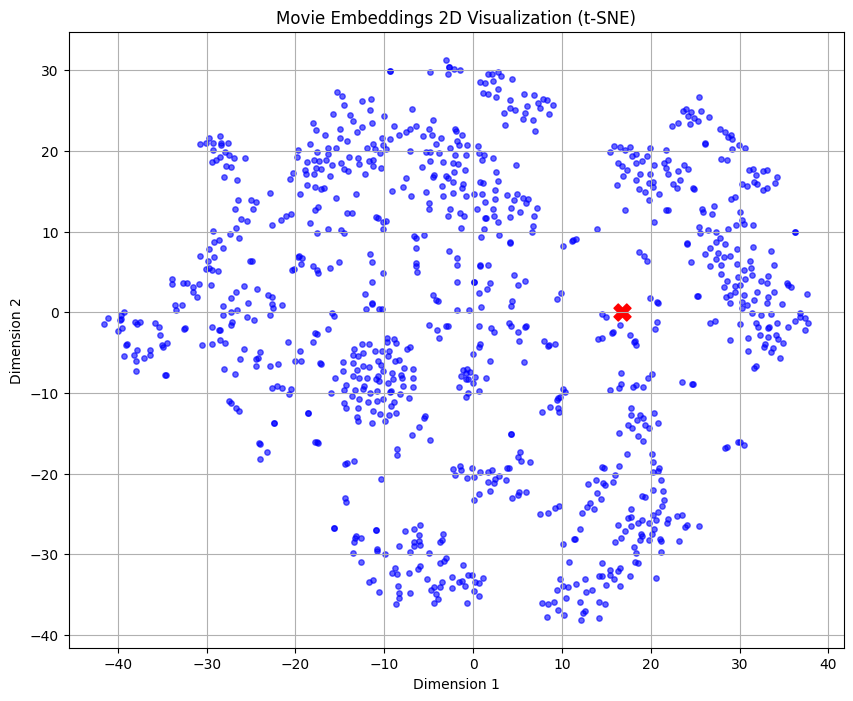

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# 1. t-SNE 모델 초기화 및 2차원으로 학습/변환 (시간이 조금 걸릴 수 있습니다)
# perplexity: 보통 5 ~ 50 사이의 값을 주며, 군집의 촘촘함을 결정합니다.
combined_embeddings = np.vstack([all_movie_embeddings, predictions["query_embeddings"]])

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
combined_2d = tsne.fit_transform(combined_embeddings)

movie_embeddings_2d = combined_2d[:movies_count, :]
user_query_2d = combined_2d[movies_count, :]

# 2. Matplotlib을 이용한 2D 산점도(Scatter Plot) 시각화
plt.figure(figsize=(10, 8))
# x축엔 0번째 열, y축엔 1번째 열의 데이터를 넣고 점(산점도)을 찍습니다.
plt.scatter(movie_embeddings_2d[:, 0], movie_embeddings_2d[:, 1], alpha=0.6, s=15, c='blue')

plt.scatter(user_query_2d[0], user_query_2d[1], c='red', marker='X', s=150)

plt.title("Movie Embeddings 2D Visualization (t-SNE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

In [31]:
predictions = keras.ops.convert_to_numpy(predictions["predictions"])
predictions

array([[1566, 1405,  783,  661, 1688, 2394, 2876, 2294, 1907, 1064]],
      dtype=int32)

In [32]:
print("\n==> Recommended movies for the above sequence:")
for movie_id in predictions[0]:
    print(movie_id_to_movie_title[movie_id])


==> Recommended movies for the above sequence:
Hercules (1997)
Beavis and Butt-head Do America (1996)
Hunchback of Notre Dame, The (1996)
James and the Giant Peach (1996)
Anastasia (1997)
Prince of Egypt, The (1998)
Thumbelina (1994)
Antz (1998)
Mulan (1998)
Aladdin and the King of Thieves (1996)
